# Video understanding with V-JEPA 2.1 and OpenVINO

[V-JEPA 2](https://ai.meta.com/vjepa/) (Video Joint-Embedding Predictive Architecture) is a self-supervised video model from Meta AI. Unlike a classifier, it is never trained to name what it sees. It is trained to **predict masked parts of a video in its own representation space** rather than in pixel space, which forces the representation to capture the structure that actually matters such as objects, surfaces and motion, while discarding unpredictable low-level detail.

The result is a general-purpose video encoder. It emits a grid of patch embeddings that can be reused for retrieval, segmentation, action recognition, robotic planning or motion analysis, usually with nothing more than a small head trained on top. **V-JEPA 2.1** refines this recipe with a distilled encoder family and 3D rotary position embeddings (RoPE) over the (time, height, width) token grid.

This tutorial takes the encoder end to end with OpenVINO:

* rebuild the encoder from the released checkpoint, in a form designed to map cleanly onto OpenVINO ops,
* convert it to OpenVINO Intermediate Representation and verify the conversion is numerically faithful,
* look inside the embeddings to see what the model learned without labels,
* use V-JEPA's *predictive* latent space to localize motion with no labels and no optical flow,
* benchmark, and perform INT8 quantization.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [The V-JEPA 2.1 encoder](#The-V-JEPA-2.1-encoder)
    - [Load the checkpoint](#Load-the-checkpoint)
    - [Prepare the input clip](#Prepare-the-input-clip)
    - [Run the PyTorch model](#Run-the-PyTorch-model)
- [Convert the model to OpenVINO IR](#Convert-the-model-to-OpenVINO-IR)
- [Run OpenVINO model inference](#Run-OpenVINO-model-inference)
    - [Select inference device](#Select-inference-device)
    - [Verify the conversion](#Verify-the-conversion)
- [What do the embeddings encode?](#What-do-the-embeddings-encode?)
    - [Spatial semantics](#Spatial-semantics)
    - [Temporal structure](#Temporal-structure)
- [Label-free motion localization](#Label-free-motion-localization)
- [Benchmark](#Benchmark)
- [Quantization](#Quantization)
    - [Run quantization](#Run-quantization)
    - [Compare accuracy and size](#Compare-accuracy-and-size)
- [Interactive demo](#Interactive-demo)

### Installation Instructions

We recommend running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
%pip install -q "openvino>=2024.4.0" "nncf>=2.14.0"
%pip install -q "torch>=2.3" torchvision --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "opencv-python" "matplotlib>=3.4" "scikit-learn" "ipywidgets" "tqdm"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


The encoder definition, checkpoint loader and video preprocessing live in `vjepa2_helper.py` next to this notebook.

In [2]:
from pathlib import Path

import numpy as np
import torch
import openvino as ov
import matplotlib.pyplot as plt

import vjepa2_helper as vjepa

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

OV_ENCODER_PATH = MODEL_DIR / "vjepa2_encoder.xml"
OV_ENCODER_INT8_PATH = MODEL_DIR / "vjepa2_encoder_int8.xml"

core = ov.Core()

Next we need a V-JEPA 2.1 encoder checkpoint (a `.pt` file such as `vjepa2_1_vitl_dist_vitG_384.pt`) and a short video clip.

The cell below searches the usual locations. If no checkpoint is found, set `CHECKPOINT_PATH` manually to point at your own download.

In [4]:
CHECKPOINT_PATH = Path("/home/rohit/openvino-vjepa2/pretrained/vjepa2_1_vitl_dist_vitG_384.pt")

if CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "No V-JEPA 2.1 checkpoint found.\n"
        "Download an encoder checkpoint (e.g. vjepa2_1_vitl_dist_vitG_384.pt) and either\n"
        "  * place it in a 'pretrained/' folder next to this notebook, or\n"
        "  * set CHECKPOINT_PATH = Path('/path/to/checkpoint.pt') here."
    )

print(f"Using checkpoint: {CHECKPOINT_PATH}  ({CHECKPOINT_PATH.stat().st_size / 2**20:.0f} MB)")

Using checkpoint: /home/rohit/openvino-vjepa2/pretrained/vjepa2_1_vitl_dist_vitG_384.pt  (4913 MB)


In [5]:
VIDEO_PATH = Path("/home/rohit/openvino-vjepa2/sample_video.mp4")

if not VIDEO_PATH.exists():
    # Fall back to a clip already present in the parent project, otherwise download one.
    local = Path("../sample_video.mp4")
    if local.exists():
        VIDEO_PATH = local
    else:
        import urllib.request

        url = (
            "https://huggingface.co/datasets/nateraw/kinetics-mini/resolve/main/val/"
            "bowling/-WH-lxmGJVY_000005_000015.mp4"
        )
        urllib.request.urlretrieve(url, VIDEO_PATH)

print(f"Using video: {VIDEO_PATH}")

Using video: /home/rohit/openvino-vjepa2/sample_video.mp4


## The V-JEPA 2.1 encoder
[back to top ⬆️](#Table-of-contents:)

The encoder is a Vision Transformer over **space and time**. A clip of 8 frames at 384×384 is tokenized by a strided 3D convolution that consumes 2 frames × 16 × 16 pixels per token:

```
clip [1, 3, 8, 384, 384]
  └─ Conv3d(kernel=(2,16,16), stride=(2,16,16))
       → 4 temporal groups × 24 × 24 patches  =  2304 tokens
```

Those 2304 tokens then pass through the transformer blocks and a final LayerNorm, producing one embedding vector per token. Position is injected with **3D factored RoPE**: each attention head's channels are split into three groups that are rotated by the token's frame index, row and column respectively, so the model knows *when* and *where* each token came from.

### Load the checkpoint
[back to top ⬆️](#Table-of-contents:)

The architecture is inferred from the checkpoint's tensor shapes rather than hardcoded, so the same notebook works across encoder sizes.

In [6]:
pt_model, cfg = vjepa.load_encoder(CHECKPOINT_PATH)

print(
    f"\nInput   : [1, 3, {vjepa.NUM_FRAMES}, {vjepa.IMG_SIZE}, {vjepa.IMG_SIZE}]\n"
    f"Tokens  : {cfg['t']} temporal groups x {cfg['h_patches']}x{cfg['w_patches']} patches"
    f" = {cfg['n_tokens']}\n"
    f"Output  : [1, {cfg['n_tokens']}, {cfg['embed_dim']}]"
)

Detected architecture: embed_dim=1024, depth=24, num_heads=16, mlp_hidden=4096  (~305M params)

Input   : [1, 3, 8, 384, 384]
Tokens  : 4 temporal groups x 24x24 patches = 2304
Output  : [1, 2304, 1024]


### Prepare the input clip
[back to top ⬆️](#Table-of-contents:)

8 frames are sampled uniformly across the whole video, resized short-side-first, center cropped to 384×384 and normalized with ImageNet statistics.

model input (1, 3, 8, 384, 384)   display frames (8, 384, 384, 3)


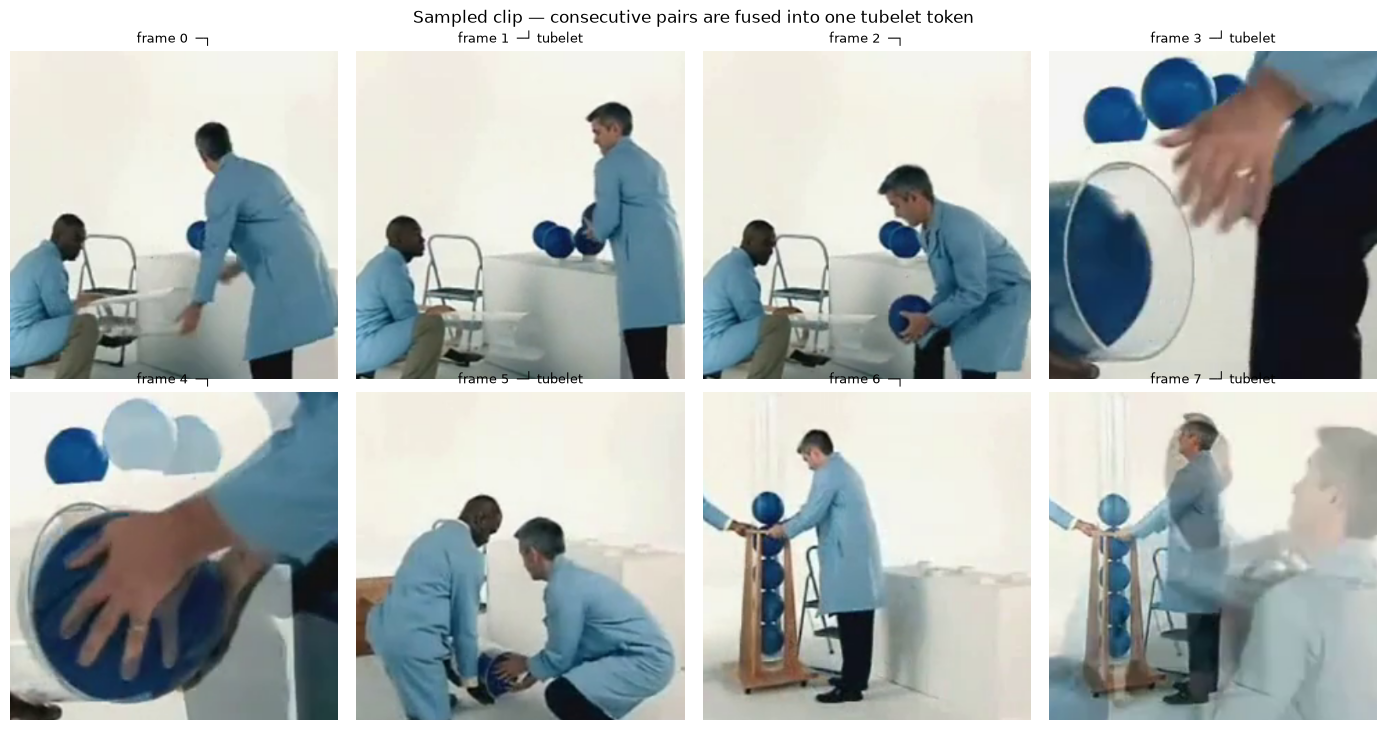

In [7]:
clip, frames = vjepa.load_video_clip(VIDEO_PATH)
print(f"model input {clip.shape}   display frames {frames.shape}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7.4))
for i, ax in enumerate(axes.flat):
    ax.imshow(frames[i])
    ax.set_title(f"frame {i}" + ("  ─┐" if i % 2 == 0 else "  ─┘ tubelet"), fontsize=9)
    ax.axis("off")
fig.suptitle("Sampled clip — consecutive pairs are fused into one tubelet token", fontsize=12)
fig.tight_layout()

### Run the PyTorch model
[back to top ⬆️](#Table-of-contents:)

This runs on CPU in FP32 and gives us a reference to validate the converted model against.

In [8]:
with torch.no_grad():
    pt_embeddings = pt_model(torch.from_numpy(clip)).numpy()

print(f"embeddings {pt_embeddings.shape}   mean {pt_embeddings.mean():+.4f}   std {pt_embeddings.std():.4f}")

embeddings (1, 2304, 1024)   mean -0.0201   std 1.9710


## Convert the model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). `ov.convert_model` accepts the PyTorch model instance plus an example input for tracing and returns an `ov.Model`, which `ov.save_model` writes to disk.

We pin the input to a static shape. The clip geometry is fixed by the architecture anyway, and static shapes let the runtime resolve every tensor size at compile time instead of emitting shape-inference subgraphs.

In [9]:
if not OV_ENCODER_PATH.exists():
    example_input = torch.from_numpy(clip)
    ov_model = ov.convert_model(
        pt_model,
        example_input=example_input,
        input=[ov.PartialShape(list(example_input.shape))],
    )
    ov_model.inputs[0].get_tensor().set_names({"clip"})
    ov_model.outputs[0].get_tensor().set_names({"embeddings"})
    ov.save_model(ov_model, OV_ENCODER_PATH)
    print("Converted and saved.")
else:
    print(f"{OV_ENCODER_PATH} already exists, skipping conversion.")

ov_model = core.read_model(OV_ENCODER_PATH)
print(f"IR operations : {len(ov_model.get_ordered_ops())}")
print(f"Weights size  : {OV_ENCODER_PATH.with_suffix('.bin').stat().st_size / 2**20:.1f} MB")

Converted and saved.
IR operations : 2087
Weights size  : 580.2 MB


## Run OpenVINO model inference
[back to top ⬆️](#Table-of-contents:)

### Select inference device
[back to top ⬆️](#Table-of-contents:)

Set `DEVICE` to one of the available devices printed below (`"AUTO"` lets OpenVINO pick).

In [10]:
print("Available devices:", core.available_devices + ["AUTO"])

DEVICE = "GPU"  # change to e.g. "GPU", "CPU", or "NPU" and re-run this cell
print(f"Using device: {DEVICE}")

Available devices: ['CPU', 'GPU.0', 'GPU.1', 'AUTO']
Using device: GPU


In [11]:
compiled_model = core.compile_model(ov_model, DEVICE)

ov_embeddings = compiled_model(clip)[compiled_model.outputs[0]]
print(f"embeddings {ov_embeddings.shape}   mean {ov_embeddings.mean():+.4f}   std {ov_embeddings.std():.4f}")

embeddings (1, 2304, 1024)   mean -0.0201   std 1.9711


### Verify the conversion
[back to top ⬆️](#Table-of-contents:)

An embedding model has no accuracy score of its own, so "is it still correct?" has to be answered by comparing representations directly. Absolute error alone is not meaningful. What matters is whether the vectors still *point the same way*, since every downstream use (retrieval, linear probes, clustering) depends on direction rather than magnitude.

We therefore report the **cosine similarity** over the whole feature map.

These are measured against the Pytorch run we executed above.

In [13]:
import copy

with torch.no_grad():
    fp16_embeddings = copy.deepcopy(pt_model).half()(torch.from_numpy(clip).half()).float().numpy()

converted = vjepa.embedding_metrics(pt_embeddings, np.asarray(ov_embeddings))

header = f"{'cosine':>16}"
print(header)
print("-" * len(header))
for name, m in [("OpenVINO IR", converted)]:
    print(f"{m['cosine']:>16.10f}")
print("-" * len(header))

          cosine
----------------
    0.9998830474
----------------


## Quantization
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf/) enables post-training quantization by adding quantization layers into the model graph and then using a subset of a representative dataset to calibrate them. `INT8` operations execute faster and the weights are roughly half the size.

The optimization process contains the following steps:

1. Create a calibration dataset for quantization.
2. Run `nncf.quantize()` to obtain a quantized model.
3. Save the `INT8` model using `openvino.save_model()`.

Two settings matter a great deal for a model like this, and both are easy to get wrong:

* **Calibration data must be real video.** Quantization scales are derived from observed activation ranges. Random tensors produce activation statistics that a real clip never generates, which yields scales that are simply wrong.
* **`model_type=nncf.ModelType.TRANSFORMER` is essential.** Transformers concentrate huge magnitudes in a few activation channels. Default post-training quantization sets one shared scale per tensor, so those outliers stretch the scale and everything else collapses into a handful of quantization levels. The transformer preset handles attention and per-channel weights appropriately.

Select whether to run quantization below. It takes several minutes.

In [15]:
to_quantize = True

### Run quantization
[back to top ⬆️](#Table-of-contents:)

The calibration set is built from the same video by varying the sampling window and stride, plus a horizontal flip on alternate samples, so the clips differ from one another while staying realistic.

In [16]:
if to_quantize and not OV_ENCODER_INT8_PATH.exists():
    import nncf

    rng = np.random.RandomState(0)
    base_clip, _ = vjepa.load_video_clip(VIDEO_PATH)

    calibration_data = []
    for i in range(16):
        sample = base_clip.copy()
        if i % 2:
            sample = sample[..., ::-1].copy()          # horizontal flip
        sample = np.roll(sample, shift=i % vjepa.NUM_FRAMES, axis=2)  # shift in time
        # Mild photometric jitter keeps activation ranges realistic while adding variety.
        sample = sample * rng.uniform(0.95, 1.05) + rng.uniform(-0.05, 0.05)
        calibration_data.append(sample.astype(np.float32))

    quantized = nncf.quantize(
        model=core.read_model(OV_ENCODER_PATH),
        calibration_dataset=nncf.Dataset(calibration_data),
        preset=nncf.QuantizationPreset.MIXED,
        model_type=nncf.ModelType.TRANSFORMER,
        subset_size=len(calibration_data),
    )
    ov.save_model(quantized, OV_ENCODER_INT8_PATH)
    print("Quantized model saved.")
elif to_quantize:
    print(f"{OV_ENCODER_INT8_PATH} already exists, skipping quantization.")
else:
    print("Quantization skipped. Tick the checkbox above and re-run to enable it.")

Output()

Output()

Output()

Output()

Quantized model saved.


### Compare accuracy and size
[back to top ⬆️](#Table-of-contents:)

The same metrics used to validate the conversion apply here.

In [17]:
if OV_ENCODER_INT8_PATH.exists():
    int8_compiled = core.compile_model(OV_ENCODER_INT8_PATH, DEVICE)
    int8_embeddings = int8_compiled(clip)[int8_compiled.outputs[0]]
    int8_metrics = vjepa.embedding_metrics(pt_embeddings, np.asarray(int8_embeddings))

    print(header)
    print("-" * len(header))
    for name, m in [("OpenVINO IR", converted),
                    ("INT8", int8_metrics)]:
        print(f"{name:<26}{m['cosine']:>16.10f}")
    print("-" * len(header))

    fp16_mb = OV_ENCODER_PATH.with_suffix(".bin").stat().st_size / 2**20
    int8_mb = OV_ENCODER_INT8_PATH.with_suffix(".bin").stat().st_size / 2**20
    print(f"\nFP32 IR size : {fp16_mb:.1f} MB")
    print(f"INT8 IR size : {int8_mb:.1f} MB")
    print(f"Compression  : {fp16_mb / int8_mb:.2f}x")    
else:
    print("No INT8 model available — enable quantization above to populate this comparison.")

          cosine
----------------
OpenVINO IR                   0.9998830474
INT8                          0.9903454663
----------------

FP32 IR size : 580.2 MB
INT8 IR size : 292.2 MB
Compression  : 1.99x
